Import packages

In [1]:
!pip install textblob
import pandas as pd
import matplotlib.pyplot as plt
import string
import nltk
from nltk.corpus import stopwords
from textblob import TextBlob
from collections import Counter

Import data and clean text

In [2]:
nltk.download('stopwords')

def clean_text(text):
    if pd.isnull(text):
        return ""
    tokens = text.lower().translate(str.maketrans('', '', string.punctuation)).split()
    return ' '.join([word for word in tokens if word not in stopwords.words('english')])

df = pd.read_csv('/glassdoor_reviews.csv')
df['review_pros_cleaned'] = df['review_pros'].apply(clean_text)
df['summary_cleaned'] = df['summary'].apply(clean_text)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Count and visualize keywords

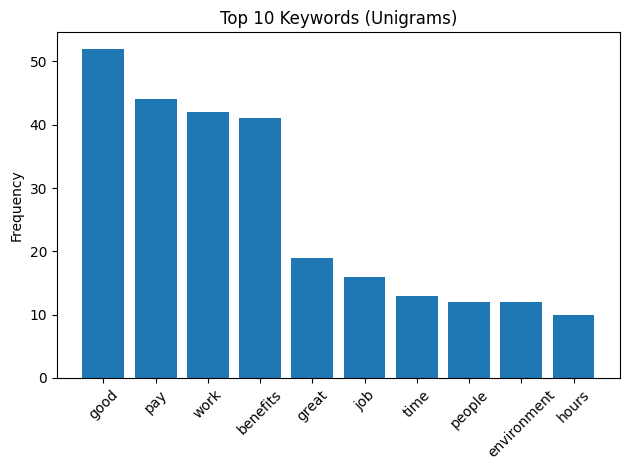

In [3]:
all_words = ' '.join(df['review_pros_cleaned']).split()
word_counts = Counter(all_words)
most_common = word_counts.most_common(10)
words, counts = zip(*most_common)

plt.bar(words, counts)
plt.title("Top 10 Keywords (Unigrams)")
plt.xticks(rotation=45)
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

Generate and categorize sentiment scores then visualize and export data

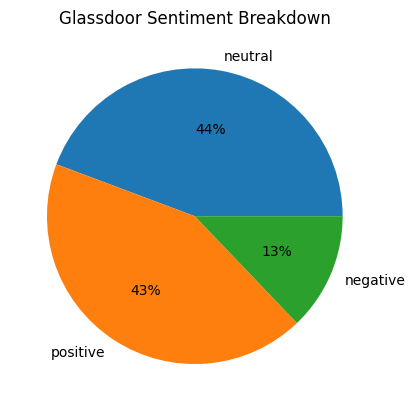

In [4]:
df['sentiment_polarity'] = df['summary_cleaned'].apply(lambda x: TextBlob(x).sentiment.polarity)

def label_sentiment(score):
    if score > 0.1:
        return 'positive'
    elif score < -0.1:
        return 'negative'
    else:
        return 'neutral'

df['sentiment_label'] = df['sentiment_polarity'].apply(label_sentiment)

df['sentiment_label'].value_counts().plot(
    kind='pie',
    autopct='%1.0f%%',
    title="Glassdoor Sentiment Breakdown"
)
plt.ylabel('')
plt.show()

df.to_csv('glassdoor_sentiment.csv', index=False)